# Downstream Evaluation — LLM Feature Selection on MIMIC-IV

폴더 2에서 얻은 LLM 변수 선택 결과가 **실제 섬망 예측 성능으로 이어지는지** 평가한다.

| 폴더 | 역할 |
|---|---|
| 2. feature selection experiment | LLM API 호출 · 순위 산출 |
| 3. analyze feature selection method | 순위의 일관성 · 상관 분석 |
| **4. evaluation with MIMIC-IV** | **downstream 예측 성능 평가 (이 노트북)** |

**입력**  `mimic_iv_dataset_107` · `results/aggregate/combined_ranks.csv` · `feature_pool.txt`
**출력**  `outputs/` — 매핑 감사, 결측 진단, k sweep, 모델 비교, 민감도 분석

### 구버전 대비 변경점
1. **107개 전수 매핑.** 구버전은 63개만 매핑되어 나머지 44개는 top-k 에 뽑혀도 조용히 버려졌다.
2. **결측 처리 정책 분리.** XGBoost·LightGBM 은 NaN 을 그대로 받아 결측 패턴을 학습한다.
3. **메타 컬럼 차단.** `icu_hours` 등 시점 위반 컬럼이 예측변수에 섞이지 않도록 assert.
4. **민감도 분석 추가.** 결측률 기준 제외 버전을 부가 보고.

## §0. 설정 · 데이터 적재

In [1]:
# =============================================================================
# 0-1. 설정 — 대부분의 변경은 이 셀 하나만 고치면 된다.
# =============================================================================
import os, re, json, itertools
import numpy as np
import pandas as pd

_MARKERS = ('1. feature pool generator', '2. feature selection experiment')

def find_root(start=None, max_up=6):
    cur = os.path.abspath(start or os.getcwd())
    for _ in range(max_up):
        if all(os.path.isdir(os.path.join(cur, m)) for m in _MARKERS):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    raise RuntimeError('프로젝트 루트를 찾지 못했습니다. ROOT 를 직접 지정하세요.')

ROOT = find_root()
DIR1 = os.path.join(ROOT, '1. feature pool generator')
DIR2 = os.path.join(ROOT, '2. feature selection experiment')
DIR4 = os.path.join(ROOT, '4. evaluation with MIMIC-IV')

AGG_DIR = os.path.join(DIR2, 'results', 'aggregate')
OUT     = os.path.join(DIR4, 'outputs')
os.makedirs(OUT, exist_ok=True)

POOL_FILE = os.path.join(DIR1, 'feature_pool.txt')
TARGET    = 'delirium'
CV_SEED   = 42
N_SPLITS  = 5
USE_CACHE = True          # 이미 만든 결과 CSV 가 있으면 재사용

# ---- 데이터셋 파일 자동 탐색 -------------------------------------------------
_CANDIDATES = [
    os.path.join(DIR4, 'mimic_iv_dataset_107'),
    os.path.join(DIR4, 'mimic_iv_dataset_107.csv'),
]
DATA_FILE = next((p for p in _CANDIDATES if os.path.exists(p)), None)
if DATA_FILE is None:
    raise FileNotFoundError(f'데이터셋을 찾지 못했습니다. 확인한 경로:\n  ' + '\n  '.join(_CANDIDATES))

POOL     = [l.strip() for l in open(POOL_FILE, encoding='utf-8-sig') if l.strip()]
POOL_SET = set(POOL)
N_POOL   = len(POOL)

mimic = pd.read_csv(DATA_FILE, low_memory=False)
COLS  = set(mimic.columns)

print(f'ROOT      : {ROOT}')
print(f'데이터셋   : {os.path.basename(DATA_FILE)}  ({mimic.shape[0]:,}행 × {mimic.shape[1]}열)')
print(f'feature pool : {N_POOL}개')
print(f'섬망 양성  : {int(mimic[TARGET].astype(bool).sum()):,}명 '
      f'({100 * mimic[TARGET].astype(bool).mean():.2f}%)')

ROOT      : c:\Users\gykwa\kyunghee2026\yonsei\LLM-FeatureSelection-ICU-Delirium
데이터셋   : mimic_iv_dataset_107  (32,574행 × 165열)
feature pool : 107개
섬망 양성  : 2,728명 (8.37%)


In [2]:
# =============================================================================
# 0-2. 메타 컬럼 — 예측변수로 절대 사용하지 않는다.
#   icu_hours / outtime / deathtime 은 24시간 시점 이후에 확정되는 값이며,
#   특히 icu_hours 는 섬망의 '결과'로 늘어나므로 사용 시 심각한 정보 누출이 된다.
#   (폴더 1의 excluded_features.txt 규칙 2와 동일한 근거)
# =============================================================================
META_COLS = ['subject_id', 'hadm_id', 'stay_id', 'delirium_charttime', 'delirium',
             'deathtime', 'intime', 'outtime', 'rn', 'icu_hours']

leaked = [c for c in META_COLS if c in COLS and c != TARGET]
print('예측변수에서 제외되는 메타 컬럼:')
for c in leaked:
    print(f'   - {c}')

예측변수에서 제외되는 메타 컬럼:
   - subject_id
   - hadm_id
   - stay_id
   - delirium_charttime
   - deathtime
   - intime
   - outtime
   - rn
   - icu_hours


## §1. Feature pool 107개 매핑

구버전의 가장 큰 결함이 여기 있었다. pool 107개 중 63개만 매핑되어 있었고, 나머지 44개는 LLM 이 상위로 뽑아도 `unavailable` 로 집계될 뿐 모델에 들어가지 않았다. 방법마다 실제 사용 변수 수가 달라져 AUC 비교 자체가 왜곡된다. 아래에서 전수 대응을 assert 로 강제한다.

In [3]:
# =============================================================================
# 1-1. feature pool 107개 -> 데이터셋 컬럼 매핑
#   - 값이 list 이면 min/max 두 컬럼을 함께 사용한다.
#   - 전 항목이 실제 컬럼에 대응하는지 아래 1-2 에서 assert 로 검증한다.
# =============================================================================
FEATURE_MAPPING = {
    # ---- 인구학 · 행정 --------------------------------------------------
    'Age'                                                       : 'anchor_age',
    'Sex'                                                       : 'sex',
    'Ethnicity'                                                 : 'ethnicity',
    'Insurance'                                                 : 'insurance',
    'Marital Status'                                            : 'marital_status',
    'Type Of Initial ICU Admission'                             : 'type_of_initial_icu_admission',
    'Height'                                                    : 'height',
    'Body Weight'                                               : 'weight',
    'Body Mass Index'                                           : 'body_mass_index',
    # ---- 동반질환 ------------------------------------------------------
    'Anemia'                                                    : 'has_anemia',
    'Alcohol Abuse'                                             : 'alcohol_abuse',
    'Cancer'                                                    : 'cancer',
    'Cardiovascular Disease'                                    : 'cardiovascular_disease',
    'Cerebrovascular Disease'                                   : 'cerebrovascular_disease',
    'Charlson Comorbidity Index'                                : 'charlson_comorbidity_index',
    'Chronic Obstructive Pulmonary Disease'                     : 'copd',
    'Dementia'                                                  : 'dementia',
    'Depression'                                                : 'depression',
    'Diabetes'                                                  : 'diabetes',
    'Heart Failure'                                             : 'heart_failure',
    'Hypertension'                                              : 'hypertension',
    'Liver Disease'                                             : 'liver_disease',
    'Nicotine Dependence'                                       : 'nicotine_dependence',
    'Peripheral Vascular Disease'                               : 'peripheral_vascular_disease',
    'Renal Disease'                                             : 'renal_disease',
    'Acute Myocardial Infarction'                               : 'acute_myocardial_infarction',
    'Stroke'                                                    : 'stroke',
    # ---- 수술 · 처치 ---------------------------------------------------
    'Aortic Surgery'                                            : 'aortic_surgery',
    'Coronary Artery Bypass Grafting'                           : 'cabg',
    'Heart Valve Surgery'                                       : 'heart_valve_surgery',
    'Elective Surgery'                                          : 'elective_surgery',
    'Mechanical Ventilation'                                    : 'mechanical_ventilation',
    'Renal Replacement Therapy'                                 : 'renal_replacement_therapy',
    # ---- 중증도 점수 ----------------------------------------------------
    'Acute Physiology and Chronic Health Evaluation (APACHE) Score': 'apache_score',
    'Glasgow Coma Scale'                                        : 'gcs_min',
    'Logistic Organ Dysfunction Score'                          : 'logistic_organ_dysfunction_score',
    'Oxford Acute Severity Of Illness Score'                    : 'oxford_acute_severity_of_illness_score',
    'Sequential Organ Failure Assessment Score'                 : 'sofa_score',
    'Simplified Acute Physiology Score II'                      : 'simplified_acute_physiology_score_ii',
    'Systemic Inflammatory Response Syndrome'                   : 'systemic_inflammatory_response_syndrome',
    # ---- 감염 --------------------------------------------------------
    'Sepsis'                                                    : 'sepsis',
    'Infection'                                                 : 'infection',
    'Gram Positive'                                             : 'micro_gram_positive',
    'Gram Negative'                                             : 'micro_gram_negative',
    'Type Of Microorganism'                                     : 'micro_category',
    'Antibiotic Drug Use'                                       : 'antibiotic_drug_use',
    # ---- 활력징후 ------------------------------------------------------
    'Diastolic Blood Pressure'                                  : ['diastolic_blood_pressure_min', 'diastolic_blood_pressure_max'],
    'Systolic Blood Pressure'                                   : ['systolic_blood_pressure_min', 'systolic_blood_pressure_max'],
    'Mean Blood Pressure'                                       : ['mean_blood_pressure_min', 'mean_blood_pressure_max'],
    'Heart Rate'                                                : ['heart_rate_min', 'heart_rate_max'],
    'Oxygen Saturation'                                         : ['oxygen_saturation_min', 'oxygen_saturation_max'],
    'Respiratory Rate'                                          : ['respiratory_rate_min', 'respiratory_rate_max'],
    'Temperature'                                               : ['temperature_min', 'temperature_max'],
    # ---- 혈액검사 ------------------------------------------------------
    'Hematocrit'                                                : ['hematocrit_min', 'hematocrit_max'],
    'Hemoglobin'                                                : ['hemoglobin_min', 'hemoglobin_max'],
    'Platelet Count'                                            : ['platelet_count_min', 'platelet_count_max'],
    'Red Blood Cell Count'                                      : ['rbc_min', 'rbc_max'],
    'Red Cell Distribution Width'                               : ['rdw_min', 'rdw_max'],
    'Mean Corpuscular Volume'                                   : ['mcv_min', 'mcv_max'],
    'Mean Corpuscular Hemoglobin'                               : ['mch_min', 'mch_max'],
    'Mean Corpuscular Hemoglobin Concentration'                 : ['mchc_min', 'mchc_max'],
    'White Blood Cell Count'                                    : ['white_blood_cell_count_min', 'white_blood_cell_count_max'],
    'Lymphocyte Count'                                          : ['lymphocyte_count_min', 'lymphocyte_count_max'],
    'Monocyte Count'                                            : ['monocyte_count_min', 'monocyte_count_max'],
    'Neutrophil Count'                                          : ['neutrophil_count_min', 'neutrophil_count_max'],
    # ---- 전해질 · 화학 --------------------------------------------------
    'Blood Sodium'                                              : ['blood_sodium_min', 'blood_sodium_max'],
    'Potassium'                                                 : ['potassium_min', 'potassium_max'],
    'Chloride'                                                  : ['chloride_min', 'chloride_max'],
    'Calcium'                                                   : ['calcium_min', 'calcium_max'],
    'Magnesium'                                                 : ['magnesium_min', 'magnesium_max'],
    'Phosphate'                                                 : ['phosphate_min', 'phosphate_max'],
    'Bicarbonate'                                               : ['bicarbonate_min', 'bicarbonate_max'],
    'Anion Gap'                                                 : ['anion_gap_min', 'anion_gap_max'],
    'Blood Urea Nitrogen'                                       : ['blood_urea_nitrogen_min', 'blood_urea_nitrogen_max'],
    'Creatinine'                                                : ['creatinine_min', 'creatinine_max'],
    'Glucose'                                                   : ['glucose_min', 'glucose_max'],
    'Albumin'                                                   : ['albumin_min', 'albumin_max'],
    'Bilirubin'                                                 : ['bilirubin_min', 'bilirubin_max'],
    # ---- 간효소 · 응고 --------------------------------------------------
    'Alanine Aminotransferase'                                  : ['alanine_aminotransferase_min', 'alanine_aminotransferase_max'],
    'Aspartate Aminotransferase'                                : ['aspartate_aminotransferase_min', 'aspartate_aminotransferase_max'],
    'Alkaline Phosphatase'                                      : ['alkaline_phosphatase_min', 'alkaline_phosphatase_max'],
    'Prothrombin Time'                                          : ['prothrombin_time_min', 'prothrombin_time_max'],
    'Partial Thromboplastin Time'                               : ['partial_thromboplastin_time_min', 'partial_thromboplastin_time_max'],
    'International Normalized Ratio'                            : ['international_normalized_ratio_min', 'international_normalized_ratio_max'],
    # ---- 혈액가스 ------------------------------------------------------
    'Blood pH'                                                  : ['blood_ph_min', 'blood_ph_max'],
    'Arterial Partial Pressure Of Oxygen'                       : ['arterial_partial_pressure_of_oxygen_min', 'arterial_partial_pressure_of_oxygen_max'],
    'Arterial Partial Pressure Of Carbon Dioxide'               : ['arterial_partial_pressure_of_carbon_dioxide_min', 'arterial_partial_pressure_of_carbon_dioxide_max'],
    'Base Excess'                                               : ['base_excess_min', 'base_excess_max'],
    'Total Carbon Dioxide'                                      : ['total_carbon_dioxide_min', 'total_carbon_dioxide_max'],
    'Lactate'                                                   : ['lactate_min', 'lactate_max'],
    # ---- 약물 --------------------------------------------------------
    'Sedation Use'                                              : 'sedation_use',
    'Use Of Midazolam'                                          : 'use_of_midazolam',
    'Vasopressor Use'                                           : 'vasopressor_use',
    'Statin Drugs'                                              : 'statin_drugs',
    # ---- 신기능 · 소변 --------------------------------------------------
    'Acute Kidney Injury'                                       : 'acute_kidney_injury',
    'Urine Output'                                              : 'urine_output',
    'Glomerular Filtration Rate'                                : 'egfr',
    # ---- 혈당 변동성 ----------------------------------------------------
    'Mean Blood Glucose'                                        : 'mean_blood_glucose',
    'Mean Absolute Glucose'                                     : 'mean_absolute_glucose',
    'Mean Amplitude Of Glycemic Excursions'                     : 'mage',
    'Largest Amplitude Of Glycemic Excursions'                  : 'lage',
    'Glycemic Lability Index'                                   : 'gli',
    'Glycemic Lability Index'                                   : 'gli',
    # ---- 영양 · 염증지표 -------------------------------------------------
    'Geriatric Nutritional Risk Index'                          : 'gnri',
    'Prognostic Nutritional Index'                              : 'prognostic_nutritional_index',
    'Lymphocyte To Monocyte Ratio'                              : 'lymphocyte_to_monocyte_ratio',
    'Neutrophil To Lymphocyte Ratio'                            : 'neutrophil_to_lymphocyte_ratio',
    'Platelet To Lymphocyte Ratio'                              : 'platelet_to_lymphocyte_ratio',
}

In [4]:
# =============================================================================
# 1-2. 매핑 감사 — pool 107개가 빠짐없이 실제 컬럼에 대응하는지 검증
#   구버전 노트북은 107개 중 63개만 매핑되어 있었고, 나머지는 top-k 에 뽑혀도
#   조용히 버려졌다. 방법별로 실제 사용 변수 수가 달라져 비교가 왜곡된다.
#   따라서 여기서 전수 검증을 강제한다.
# =============================================================================
audit = []
for f in POOL:
    v  = FEATURE_MAPPING.get(f)
    vs = [] if v is None else ([v] if isinstance(v, str) else list(v))
    ok = [c for c in vs if c in COLS]
    audit.append({'feature': f,
                  'columns': ', '.join(vs) if vs else '',
                  'n_columns': len(ok),
                  'status': 'OK' if ok and len(ok) == len(vs) else
                            ('PARTIAL' if ok else 'MISSING')})
audit_df = pd.DataFrame(audit)

missing_keys = sorted(POOL_SET - set(FEATURE_MAPPING))
extra_keys   = sorted(set(FEATURE_MAPPING) - POOL_SET)
bad          = audit_df[audit_df.status != 'OK']

print(f'pool {N_POOL}개 · 매핑 정의 {len(FEATURE_MAPPING)}개')
print(f'상태별: ' + ' / '.join(f'{k} {v}' for k, v in audit_df.status.value_counts().items()))
if missing_keys: print('\n[매핑 누락]', missing_keys)
if extra_keys:   print('[pool 밖 키]', extra_keys)
if len(bad):     display(bad)

assert not missing_keys, f'매핑에 없는 pool feature 가 있습니다: {missing_keys}'
assert not extra_keys,   f'pool 에 없는 매핑 키가 있습니다: {extra_keys}'
assert len(bad) == 0,    '실제 컬럼에 대응하지 않는 feature 가 있습니다 (위 표 참조)'

USABLE   = list(POOL)
ALL_COLS = list(dict.fromkeys(itertools.chain.from_iterable(
    ([v] if isinstance(v, str) else list(v)) for v in FEATURE_MAPPING.values())))
assert not (set(ALL_COLS) & set(META_COLS)), '메타 컬럼이 예측변수에 섞였습니다.'

audit_df.to_csv(os.path.join(OUT, 'feature_mapping_audit.csv'), index=False, encoding='utf-8-sig')
print(f'\nOK — {N_POOL}개 전부 매핑, 실제 사용 컬럼 {len(ALL_COLS)}개 '
      f'(min/max 쌍 {sum(1 for v in FEATURE_MAPPING.values() if not isinstance(v, str))}개 포함)')

pool 107개 · 매핑 정의 107개
상태별: OK 107

OK — 107개 전부 매핑, 실제 사용 컬럼 151개 (min/max 쌍 44개 포함)


## §2. 방법별 순위 벡터

In [5]:
# =============================================================================
# 2. 방법별 순위 벡터 — 폴더 2의 집계 결과에서 읽는다.
#   combined_ranks.csv 컬럼: rank_/score_/seq_ × gpt/gemini/claude + lmprior_gpt
#   값이 작을수록 상위. 각 벡터는 pool 107개와 정확히 같은 집합이어야 한다.
# =============================================================================
comb = pd.read_csv(os.path.join(AGG_DIR, 'combined_ranks.csv'), encoding='utf-8-sig')
comb.columns = [str(c).strip().strip('﻿') for c in comb.columns]
feat_col = comb.columns[0]

METHOD_COLS = [c for c in comb.columns
               if c != feat_col and c != 'mean_rank'
               and re.match(r'^(rank|score|seq|lmprior)_', c)]

METHOD_VECTORS = {}
for c in METHOD_COLS:
    v = comb[[feat_col, c]].rename(columns={feat_col: 'feature', c: 'v'}).dropna()
    METHOD_VECTORS[c] = v.reset_index(drop=True)

for name, v in METHOD_VECTORS.items():
    s = set(v['feature'])
    assert s == POOL_SET, f'{name}: pool 불일치 (없음={sorted(POOL_SET - s)}, 추가={sorted(s - POOL_SET)})'

def top_k(name, k):
    """방법 name 의 상위 k개 feature 이름"""
    return METHOD_VECTORS[name].sort_values('v').head(k)['feature'].tolist()

print(f'{len(METHOD_VECTORS)}개 방법 벡터 준비 — 전부 {N_POOL}개, 이름 일치 확인')
print(sorted(METHOD_VECTORS))

10개 방법 벡터 준비 — 전부 107개, 이름 일치 확인
['lmprior_gpt', 'rank_claude', 'rank_gemini', 'rank_gpt', 'score_claude', 'score_gemini', 'score_gpt', 'seq_claude', 'seq_gemini', 'seq_gpt']


## §3. 결측 진단 — 결측은 정보인가

EHR 에서 "검사하지 않음"은 임상적 판단의 결과다. 동맥혈가스를 뽑지 않았다면 동맥관이 없었다는 뜻이고, 이는 곧 덜 중한 환자라는 신호다. 결측을 중앙값으로 메우면 이 정보가 사라진다.

In [6]:
# =============================================================================
# 3. 결측 진단 — 결측은 '정보'인가?
#   EHR 에서 검사를 하지 않은 것은 임상적 판단의 결과다. 즉 결측 여부 자체가
#   중증도 신호일 수 있다. 그렇다면 결측을 중앙값으로 메우는 순간 그 신호가 사라진다.
#   아래에서 결측군과 관측군의 섬망 발생률·SOFA 를 비교해 실제로 그런지 확인한다.
# =============================================================================
y_all = mimic[TARGET].astype(int)

rows = []
for f in POOL:
    v    = FEATURE_MAPPING[f]
    col  = v if isinstance(v, str) else v[0]
    s    = mimic[col]
    miss = s.isna()
    if miss.sum() == 0 or miss.all():
        rate = 100 * miss.mean()
        rows.append({'feature': f, 'column': col, 'missing_pct': round(rate, 1),
                     'delirium_if_missing': np.nan, 'delirium_if_observed': np.nan,
                     'sofa_if_missing': np.nan, 'sofa_if_observed': np.nan})
        continue
    rows.append({
        'feature': f, 'column': col,
        'missing_pct': round(100 * miss.mean(), 1),
        'delirium_if_missing':  round(100 * y_all[miss].mean(), 1),
        'delirium_if_observed': round(100 * y_all[~miss].mean(), 1),
        'sofa_if_missing':      round(mimic.loc[miss,  'sofa_score'].mean(), 2),
        'sofa_if_observed':     round(mimic.loc[~miss, 'sofa_score'].mean(), 2),
    })

miss_df = (pd.DataFrame(rows)
             .assign(delirium_gap=lambda d: (d.delirium_if_observed - d.delirium_if_missing).round(1),
                     sofa_gap=lambda d: (d.sofa_if_observed - d.sofa_if_missing).round(2))
             .sort_values('missing_pct', ascending=False)
             .reset_index(drop=True))
miss_df.to_csv(os.path.join(OUT, 'missingness_diagnostics.csv'), index=False, encoding='utf-8-sig')

print('결측률 상위 15개 — 결측군 vs 관측군')
display(miss_df.head(15)[['feature', 'missing_pct', 'delirium_if_missing',
                          'delirium_if_observed', 'sofa_if_missing', 'sofa_if_observed']])

hi = miss_df[miss_df.missing_pct >= 20]
print(f'\n결측 20% 이상 {len(hi)}개 중 관측군의 섬망률이 더 높은 경우: '
      f'{int((hi.delirium_gap > 0).sum())}개')
print('→ 값이 양수라면 "검사를 한 환자가 더 아프고 섬망도 많다"는 뜻이며,')
print('   결측을 중앙값으로 대치하면 이 정보가 사라진다.')
for th in (30, 50, 70):
    print(f'   결측 {th}% 이상: {int((miss_df.missing_pct >= th).sum())}개')

결측률 상위 15개 — 결측군 vs 관측군


,feature,missing_pct,delirium_if_missing,delirium_if_observed,sofa_if_missing,sofa_if_observed
0,Geriatric Nutritional Risk Index,90.3,7.9,12.9,3.38,4.52
1,Prognostic Nutritional Index,84.7,8.0,10.3,3.28,4.67
2,Body Mass Index,73.0,7.8,9.9,3.29,4.03
3,Height,73.0,7.8,9.9,3.29,4.03
4,Lymphocyte To Monocyte Ratio,70.2,8.2,8.8,3.15,4.29
5,Neutrophil To Lymphocyte Ratio,69.9,8.2,8.7,3.13,4.31
6,Platelet To Lymphocyte Ratio,69.9,8.2,8.7,3.13,4.31
7,Neutrophil Count,69.7,8.2,8.7,3.13,4.32
8,Lactate,69.5,7.5,10.3,2.89,4.85
9,Body Weight,66.7,7.8,9.5,3.29,3.88



결측 20% 이상 22개 중 관측군의 섬망률이 더 높은 경우: 22개
→ 값이 양수라면 "검사를 한 환자가 더 아프고 섬망도 많다"는 뜻이며,
   결측을 중앙값으로 대치하면 이 정보가 사라진다.
   결측 30% 이상: 22개
   결측 50% 이상: 16개
   결측 70% 이상: 5개


## §4. 전처리 · 모델

In [7]:
# =============================================================================
# 4-1. 전처리 — 결측 처리 정책
#   NAN_NATIVE  : XGBoost / LightGBM. NaN 을 그대로 넘긴다. 두 모델은 분기마다
#                 결측의 진행 방향을 학습하므로 결측 패턴 자체를 활용한다.
#   IMPUTE      : LogisticRegression / RandomForest. NaN 을 받지 못하므로
#                 중앙값·최빈값으로 대치하되, 결측 여부를 나타내는 지시변수를
#                 함께 넣어 정보 손실을 줄인다.
# =============================================================================
NAN_NATIVE_MODELS = {'xgboost', 'lightgbm'}
ADD_MISSING_INDICATOR = True     # IMPUTE 계열에서 *_isna 지시변수 추가

def features_to_columns(feats):
    cols, unavailable = [], []
    for f in feats:
        v = FEATURE_MAPPING.get(f)
        if v is None:
            unavailable.append(f); continue
        vs = [v] if isinstance(v, str) else list(v)
        ok = [c for c in vs if c in COLS]
        if ok: cols.extend(ok)
        else:  unavailable.append(f)
    return list(dict.fromkeys(cols)), unavailable


def build_xy(cols, impute):
    """impute=False -> NaN 유지 (XGB/LGBM),  True -> 대치 + 지시변수 (LR/RF)"""
    X = mimic[cols].copy()
    y = mimic[TARGET].astype(int)

    # pandas 3 부터 문자열 컬럼은 'object' 가 아니라 'str' dtype 이 된다.
    # include=['object'] 로 잡으면 그때부터 범주형이 하나도 걸리지 않고, 아래
    # to_numeric(errors='coerce') 에서 전부 NaN 이 되어 조용히 사라진다.
    # 에러가 나지 않으므로 발견하기 어렵다. 버전 무관 기준을 쓴다.
    cat = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
    num = [c for c in X.columns if c not in cat]
    for c in num:
        X[c] = pd.to_numeric(X[c], errors='coerce')

    if impute:
        if ADD_MISSING_INDICATOR:
            # 한 컬럼씩 삽입하면 DataFrame 이 조각나 PerformanceWarning 이 뜬다
            # (frame.insert 반복). 한 번에 concat 한다. 컬럼 순서는 num 순서
            # 그대로라 결과는 이전과 동일하다.
            ind = {f'{c}_isna': X[c].isna().astype(int) for c in num if X[c].isna().any()}
            if ind:
                X = pd.concat([X, pd.DataFrame(ind, index=X.index)], axis=1)
        for c in num:
            X[c] = X[c].fillna(X[c].median())
        for c in cat:
            mode = X[c].mode(dropna=True)
            X[c] = X[c].fillna(mode.iloc[0] if len(mode) else 'Unknown')
    else:
        for c in cat:
            X[c] = X[c].fillna('__missing__')

    if cat:
        X = pd.get_dummies(X, columns=cat, drop_first=False)
    return X, y

In [8]:
# =============================================================================
# 4-2. 모델 · 교차검증
# =============================================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print('[주의] lightgbm 미설치 — 해당 모델은 건너뜁니다.')

MODEL_NAMES = ['xgboost', 'random_forest', 'logistic_regression'] + (['lightgbm'] if HAS_LGBM else [])

def make_model(name, y_train, seed=CV_SEED):
    n_pos = int((y_train == 1).sum()); n_neg = int((y_train == 0).sum())
    spw = n_neg / n_pos if n_pos else 1.0
    if name == 'logistic_regression':
        return make_pipeline(StandardScaler(),
                             LogisticRegression(max_iter=2000, class_weight='balanced',
                                                random_state=seed))
    if name == 'random_forest':
        return RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                      random_state=seed, n_jobs=-1)
    if name == 'xgboost':
        return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             objective='binary:logistic', eval_metric='auc',
                             random_state=seed, scale_pos_weight=spw,
                             tree_method='hist', n_jobs=-1)
    if name == 'lightgbm':
        return LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=seed, scale_pos_weight=spw,
                              n_jobs=-1, verbose=-1)
    raise ValueError(name)


def cv_scores(cols, model_name, seed=CV_SEED):
    """(AUROC 배열, AUPRC 배열) — 모델에 따라 결측 처리 정책이 자동으로 갈린다."""
    impute = model_name not in NAN_NATIVE_MODELS
    X, y   = build_xy(cols, impute=impute)
    skf    = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    au, ap = [], []
    for tr, te in skf.split(X, y):
        m = make_model(model_name, y.iloc[tr], seed)
        m.fit(X.iloc[tr], y.iloc[tr])
        p = m.predict_proba(X.iloc[te])[:, 1]
        au.append(roc_auc_score(y.iloc[te], p))
        ap.append(average_precision_score(y.iloc[te], p))
    return np.array(au), np.array(ap)

print('모델:', MODEL_NAMES)
print('NaN 그대로 전달:', sorted(NAN_NATIVE_MODELS & set(MODEL_NAMES)))
print('대치 + 지시변수 :', sorted(set(MODEL_NAMES) - NAN_NATIVE_MODELS))

모델: ['xgboost', 'random_forest', 'logistic_regression', 'lightgbm']
NaN 그대로 전달: ['lightgbm', 'xgboost']
대치 + 지시변수 : ['logistic_regression', 'random_forest']


## §5. Downstream 성능 — 기준선과 k sweep

In [9]:
# =============================================================================
# 5-1. 전체 107개 기준선 — 결측 처리 정책에 따라 성능이 달라지는지 확인
#   같은 변수 집합(107개 전체)을 쓰되 모델과 결측 처리만 바꿔 비교한다.
#   XGBoost 를 '대치' 로도 돌려서, 결측 정보를 버릴 때의 손실을 직접 측정한다.
# =============================================================================
_f_base = os.path.join(OUT, 'Downstream_baselines.csv')
all_cols, _ = features_to_columns(POOL)

if USE_CACHE and os.path.exists(_f_base):
    baselines = pd.read_csv(_f_base)
    print(f'[cache] {os.path.basename(_f_base)} 재사용')
else:
    rows = []
    for mname in MODEL_NAMES:
        au, ap = cv_scores(all_cols, mname)
        rows.append({'model': mname,
                     'missing_policy': 'NaN 유지' if mname in NAN_NATIVE_MODELS else '대치+지시변수',
                     'n_cols': len(all_cols),
                     'auc': round(au.mean(), 4), 'auc_std': round(au.std(ddof=0), 4),
                     'ap':  round(ap.mean(), 4)})
        print(f'  {mname:22} AUROC {au.mean():.4f}', flush=True)

    # 결측 정보의 가치 — XGBoost 를 강제로 '대치' 모드로 돌려 비교
    _orig = set(NAN_NATIVE_MODELS)
    NAN_NATIVE_MODELS.clear()
    au, ap = cv_scores(all_cols, 'xgboost')
    NAN_NATIVE_MODELS.update(_orig)
    rows.append({'model': 'xgboost (대치 강제)', 'missing_policy': '중앙값 대치',
                 'n_cols': len(all_cols),
                 'auc': round(au.mean(), 4), 'auc_std': round(au.std(ddof=0), 4),
                 'ap': round(ap.mean(), 4)})
    print(f'  {"xgboost (대치 강제)":22} AUROC {au.mean():.4f}')

    baselines = pd.DataFrame(rows).sort_values('auc', ascending=False).reset_index(drop=True)
    baselines.to_csv(_f_base, index=False, encoding='utf-8-sig')

display(baselines)
_n = baselines.set_index('model')['auc']
if 'xgboost' in _n.index and 'xgboost (대치 강제)' in _n.index:
    d = _n['xgboost'] - _n['xgboost (대치 강제)']
    print(f'\n결측을 NaN 으로 유지했을 때의 AUROC 이득: {d:+.4f}')
    print('양수라면 결측 패턴 자체가 예측 정보를 담고 있다는 뜻이다.')

  xgboost                AUROC 0.8407
  random_forest          AUROC 0.8139
  logistic_regression    AUROC 0.8102
  lightgbm               AUROC 0.8378
  xgboost (대치 강제)        AUROC 0.8410


,model,missing_policy,n_cols,auc,auc_std,ap
0,xgboost (대치 강제),중앙값 대치,151,0.8410,0.0063,0.3508
1,xgboost,NaN 유지,151,0.8407,0.0056,0.3496
2,lightgbm,NaN 유지,151,0.8378,0.0063,0.3466
3,random_forest,대치+지시변수,151,0.8139,0.0066,0.2870
4,logistic_regression,대치+지시변수,151,0.8102,0.0071,0.3025



결측을 NaN 으로 유지했을 때의 AUROC 이득: -0.0003
양수라면 결측 패턴 자체가 예측 정보를 담고 있다는 뜻이다.


In [10]:
# =============================================================================
# 5-2. 메인 실험 — k sweep (XGBoost)
#   LLM 선택 10종 + 대조군 2종(무작위 k개 · 하위 k개)을 k = 5 … 107 전 구간에서 비교.
#   k=107 은 전체 변수 사용이므로 세 계열이 한 점으로 수렴해야 정상이다.
# =============================================================================
K_SWEEP  = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, N_POOL]
K_SWEEP  = sorted(set(k for k in K_SWEEP if k <= N_POOL))
N_RANDOM = 5
SWEEP_MODEL = 'xgboost'
_f_sweep = os.path.join(OUT, 'Downstream_ksweep.csv')

def _one(feats):
    cols, _ = features_to_columns(feats)
    au, ap = cv_scores(cols, SWEEP_MODEL)
    return float(au.mean()), float(au.std(ddof=0)), float(ap.mean()), len(cols)

if USE_CACHE and os.path.exists(_f_sweep):
    sweep_df = pd.read_csv(_f_sweep)
    print(f'[cache] {os.path.basename(_f_sweep)} 재사용')
else:
    worst_key = 'lmprior_gpt' if 'lmprior_gpt' in METHOD_VECTORS else sorted(METHOD_VECTORS)[0]
    worst_vec = METHOD_VECTORS[worst_key].sort_values('v')
    sweep = []
    for k in K_SWEEP:
        for name in sorted(METHOD_VECTORS):
            au, sd, ap, nc = _one(top_k(name, k))
            sweep.append({'selection': name, 'family': 'llm', 'k': k, 'n_cols': nc,
                          'auc': round(au, 4), 'std': round(sd, 4), 'ap': round(ap, 4)})
        rng = np.random.default_rng(CV_SEED + k)
        r_au, r_ap, r_nc = [], [], []
        for _ in range(N_RANDOM):
            pick = list(rng.choice(POOL, size=min(k, N_POOL), replace=False))
            au, sd, ap, nc = _one(pick)
            r_au.append(au); r_ap.append(ap); r_nc.append(nc)
        sweep.append({'selection': f'BASELINE_random (mean of {N_RANDOM})', 'family': 'baseline',
                      'k': k, 'n_cols': int(np.mean(r_nc)),
                      'auc': round(float(np.mean(r_au)), 4),
                      'std': round(float(np.std(r_au, ddof=0)), 4),
                      'ap':  round(float(np.mean(r_ap)), 4)})
        au, sd, ap, nc = _one(worst_vec.tail(k)['feature'].tolist())
        sweep.append({'selection': f'BASELINE_bottom ({worst_key})', 'family': 'baseline',
                      'k': k, 'n_cols': nc, 'auc': round(au, 4), 'std': round(sd, 4),
                      'ap': round(ap, 4)})
        print(f'  k={k:3d} 완료', flush=True)
    sweep_df = pd.DataFrame(sweep)
    sweep_df.to_csv(_f_sweep, index=False, encoding='utf-8-sig')

pivot_k = sweep_df.pivot(index='selection', columns='k', values='auc')
display(pivot_k.round(4))

  k=  5 완료
  k= 10 완료
  k= 20 완료
  k= 30 완료
  k= 40 완료
  k= 50 완료
  k= 60 완료
  k= 70 완료
  k= 80 완료
  k= 90 완료
  k=100 완료
  k=107 완료


k,5,10,20,30,40,50,60,70,80,90,100,107
selection,,,,,,,,,,,,
BASELINE_bottom (lmprior_gpt),0.5974,0.6528,0.7024,0.7170,0.7404,0.7550,0.7870,0.7939,0.8276,0.8328,0.8368,0.8410
BASELINE_random (mean of 5),0.6166,0.6862,0.7419,0.7665,0.7770,0.7896,0.8069,0.8155,0.8235,0.8323,0.8368,0.8409
lmprior_gpt,0.6598,0.6885,0.7557,0.7725,0.7971,0.8036,0.8158,0.8225,0.8233,0.8256,0.8394,0.8410
rank_claude,0.7270,0.7505,0.7609,0.7885,0.7993,0.8129,0.8145,0.8343,0.8355,0.8354,0.8391,0.8402
rank_gemini,0.7153,0.7449,0.7847,0.7919,0.7973,0.8033,0.8162,0.8354,0.8370,0.8378,0.8374,0.8402
rank_gpt,0.7040,0.7308,0.7667,0.7961,0.8097,0.8150,0.8183,0.8178,0.8247,0.8305,0.8397,0.8404
score_claude,0.7121,0.7322,0.7667,0.7727,0.7857,0.8018,0.8083,0.8191,0.8199,0.8234,0.8383,0.8403
score_gemini,0.6677,0.7189,0.7681,0.7889,0.7920,0.8137,0.8156,0.8227,0.8356,0.8366,0.8389,0.8413
score_gpt,0.6770,0.7393,0.7684,0.7761,0.7822,0.7966,0.8113,0.8278,0.8281,0.8368,0.8410,0.8402


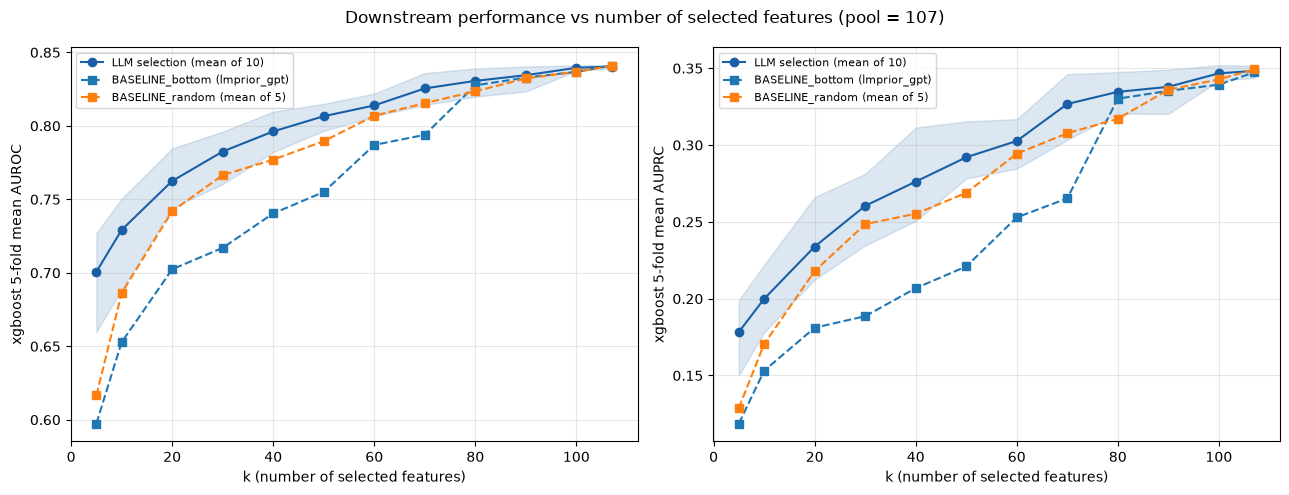

k,5,10,20,30,40,50,60,70,80,90,100,107
family2,,,,,,,,,,,,
BASELINE_bottom (lmprior_gpt),0.5974,0.6528,0.7024,0.7170,0.7404,0.7550,0.7870,0.7939,0.8276,0.8328,0.8368,0.8410
BASELINE_random (mean of 5),0.6166,0.6862,0.7419,0.7665,0.7770,0.7896,0.8069,0.8155,0.8235,0.8323,0.8368,0.8409
LLM selection (mean of 10),0.7007,0.7292,0.7625,0.7826,0.7962,0.8066,0.8139,0.8255,0.8306,0.8345,0.8395,0.8404


In [11]:
# =============================================================================
# 5-3. Figure — k sweep 시각화
# =============================================================================
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for ax, metric, ylab in [(axes[0], 'auc', f'{SWEEP_MODEL} {N_SPLITS}-fold mean AUROC'),
                         (axes[1], 'ap',  f'{SWEEP_MODEL} {N_SPLITS}-fold mean AUPRC')]:
    llm = (sweep_df[sweep_df.family == 'llm']
           .groupby('k')[metric].agg(['mean', 'min', 'max']).reset_index())
    ax.plot(llm.k, llm['mean'], marker='o', label='LLM selection (mean of 10)', color='#185FA5')
    ax.fill_between(llm.k, llm['min'], llm['max'], alpha=0.15, color='#185FA5')
    for sel, gg in sweep_df[sweep_df.family == 'baseline'].groupby('selection'):
        gg = gg.sort_values('k')
        ax.plot(gg.k, gg[metric], marker='s', linestyle='--', label=sel)
    ax.set_xlabel('k (number of selected features)'); ax.set_ylabel(ylab)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle(f'Downstream performance vs number of selected features (pool = {N_POOL})')
fig.tight_layout()
fig.savefig(os.path.join(OUT, 'Figure4_k_sweep.png'), dpi=200, bbox_inches='tight')
plt.show()

summary = (sweep_df.assign(family2=lambda d: np.where(d.family == 'baseline', d.selection,
                                                      'LLM selection (mean of 10)'))
                   .groupby(['family2', 'k'])[['auc', 'ap']].mean().round(4).reset_index())
summary.to_csv(os.path.join(OUT, 'Downstream_ksweep_summary.csv'), index=False, encoding='utf-8-sig')
display(summary.pivot(index='family2', columns='k', values='auc'))

### §5-4. 부트스트랩 신뢰구간

점추정만으로는 방법 간 차이가 실제인지 판단할 수 없다. out-of-fold 예측에서 환자를 복원추출해 AUROC 의 표본 변동을 추정한다.

두 방법을 비교할 때 **개별 신뢰구간의 겹침을 보면 안 된다.** 같은 환자를 예측하므로 표본 변동이 공통으로 작용해 개별 구간은 넓게 겹치지만, 짝지은 차이는 유의할 수 있다.

In [12]:
# =============================================================================
# 4-3. Out-of-fold 예측 · 부트스트랩 신뢰구간
#   AUROC 를 점추정 하나로 보고하면 방법 간 차이가 실제인지 판단할 수 없다.
#   교차검증 fold 간 표준편차는 '데이터를 어떻게 나눴나'의 변동이지
#   '환자 표본이 달랐다면'의 변동이 아니므로 신뢰구간으로 쓸 수 없다.
#
#   [중요] 두 방법을 비교할 때는 개별 CI 의 겹침을 보지 말고 '짝지은 차이'를
#   부트스트랩할 것. 두 모델이 같은 환자를 예측하므로 표본 변동이 공통으로
#   작용해 개별 CI 는 넓게 겹치지만 차이는 유의할 수 있다.
# =============================================================================
N_BOOT = 2000

def cv_oof(cols, model_name, seed=CV_SEED):
    """out-of-fold 예측확률 -> (y, p)"""
    impute = model_name not in NAN_NATIVE_MODELS
    X, y   = build_xy(cols, impute=impute)
    oof    = np.zeros(len(y))
    skf    = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    for tr, te in skf.split(X, y):
        m = make_model(model_name, y.iloc[tr], seed)
        m.fit(X.iloc[tr], y.iloc[tr])
        oof[te] = m.predict_proba(X.iloc[te])[:, 1]
    return y.to_numpy(), oof


def boot_ci(y, p, B=N_BOOT, seed=CV_SEED, metric=roc_auc_score):
    rng, n, out = np.random.default_rng(seed), len(y), []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        if len(np.unique(y[idx])) < 2:
            continue
        out.append(metric(y[idx], p[idx]))
    out = np.asarray(out)
    return (float(metric(y, p)),
            float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5)))


def boot_paired(y, pA, pB, B=N_BOOT, seed=CV_SEED, metric=roc_auc_score):
    """짝지은 차이(A - B)의 점추정 · 95% CI · 양측 p"""
    rng, n, d = np.random.default_rng(seed), len(y), []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        if len(np.unique(y[idx])) < 2:
            continue
        d.append(metric(y[idx], pA[idx]) - metric(y[idx], pB[idx]))
    d = np.asarray(d)
    p_two = 2 * min((d > 0).mean(), (d < 0).mean())
    return (float(metric(y, pA) - metric(y, pB)),
            float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5)),
            float(min(p_two, 1.0)))

print(f'부트스트랩 {N_BOOT}회 · out-of-fold 예측 기반')

부트스트랩 2000회 · out-of-fold 예측 기반


In [13]:
# =============================================================================
# 5-4. 방법별 AUROC 와 95% CI (k = 30)
# =============================================================================
TOP_K = 30
_f_ci = os.path.join(OUT, 'Downstream_bootstrap_ci.csv')
OOF   = {}

for name in sorted(METHOD_VECTORS):
    cols, unavail = features_to_columns(top_k(name, TOP_K))
    assert not unavail, f'{name}: 매핑 실패 {unavail}'
    OOF[name] = cv_oof(cols, 'xgboost')
    print(f'  {name:16} out-of-fold 완료', flush=True)

if USE_CACHE and os.path.exists(_f_ci):
    ci_df = pd.read_csv(_f_ci)
else:
    rows = []
    # OOF 에는 뒤 셀(§6-2)에서 통계적 기법도 추가된다. 셀을 다시 실행할 때
    # 그것들이 이 표에 섞이지 않도록 LLM 절차만 명시적으로 돈다.
    for name in sorted(METHOD_VECTORS):
        y, p = OOF[name]
        auc, lo, hi   = boot_ci(y, p)
        ap, alo, ahi  = boot_ci(y, p, metric=average_precision_score)
        rows.append({'method': name, 'k': TOP_K,
                     'auroc': round(auc, 4), 'auroc_ci': f'[{lo:.4f}, {hi:.4f}]',
                     'auprc': round(ap, 4),  'auprc_ci': f'[{alo:.4f}, {ahi:.4f}]'})
    ci_df = pd.DataFrame(rows).sort_values('auroc', ascending=False).reset_index(drop=True)
    ci_df.to_csv(_f_ci, index=False, encoding='utf-8-sig')
display(ci_df)

  lmprior_gpt      out-of-fold 완료
  rank_claude      out-of-fold 완료
  rank_gemini      out-of-fold 완료
  rank_gpt         out-of-fold 완료
  score_claude     out-of-fold 완료
  score_gemini     out-of-fold 완료
  score_gpt        out-of-fold 완료
  seq_claude       out-of-fold 완료
  seq_gemini       out-of-fold 완료
  seq_gpt          out-of-fold 완료


,method,k,auroc,auroc_ci,auprc,auprc_ci
0,rank_gpt,30,0.7958,"[0.7876, 0.8041]",0.2786,"[0.2635, 0.2956]"
1,rank_gemini,30,0.7918,"[0.7837, 0.8000]",0.2725,"[0.2577, 0.2896]"
2,seq_claude,30,0.7900,"[0.7820, 0.7986]",0.2564,"[0.2427, 0.2728]"
3,score_gemini,30,0.7889,"[0.7807, 0.7972]",0.2743,"[0.2586, 0.2912]"
4,rank_claude,30,0.7884,"[0.7805, 0.7967]",0.2667,"[0.2520, 0.2835]"
5,seq_gemini,30,0.7883,"[0.7799, 0.7966]",0.2598,"[0.2458, 0.2769]"
6,score_gpt,30,0.7759,"[0.7674, 0.7849]",0.2508,"[0.2370, 0.2664]"
7,score_claude,30,0.7725,"[0.7640, 0.7814]",0.2444,"[0.2305, 0.2599]"
8,lmprior_gpt,30,0.7724,"[0.7640, 0.7814]",0.2500,"[0.2360, 0.2666]"
9,seq_gpt,30,0.7603,"[0.7518, 0.7692]",0.2327,"[0.2186, 0.2482]"


In [14]:
# =============================================================================
# 5-5. 최고 성능 방법 대비 짝지은 차이
#   개별 CI 가 겹치더라도 짝지은 차이는 유의할 수 있다. 순위 판정은 이 표로 한다.
# =============================================================================
best = ci_df.iloc[0]['method']
rows = []
for name in sorted(OOF):
    if name == best:
        continue
    y, pB = OOF[name]
    _, pA = OOF[best]
    d, lo, hi, pv = boot_paired(y, pA, pB)
    rows.append({'reference': best, 'method': name,
                 'diff_auroc': round(d, 4), 'diff_ci': f'[{lo:+.4f}, {hi:+.4f}]',
                 'p': round(pv, 4),
                 'significant': 'yes' if (lo > 0 or hi < 0) else 'no'})
paired_df = pd.DataFrame(rows).sort_values('diff_auroc').reset_index(drop=True)
paired_df.to_csv(os.path.join(OUT, 'Downstream_paired_diff.csv'),
                 index=False, encoding='utf-8-sig')
display(paired_df)
print(f"\n{best} 대비 유의하게 낮은 방법: "
      f"{int((paired_df.significant == 'yes').sum())} / {len(paired_df)}")

,reference,method,diff_auroc,diff_ci,p,significant
0,rank_gpt,rank_gemini,0.0041,"[-0.0018, +0.0097]",0.159,no
1,rank_gpt,seq_claude,0.0058,"[-0.0003, +0.0117]",0.061,no
2,rank_gpt,score_gemini,0.0069,"[+0.0006, +0.0134]",0.035,yes
3,rank_gpt,rank_claude,0.0074,"[+0.0009, +0.0138]",0.027,yes
4,rank_gpt,seq_gemini,0.0076,"[+0.0016, +0.0134]",0.014,yes
5,rank_gpt,score_gpt,0.0199,"[+0.0143, +0.0257]",0.000,yes
6,rank_gpt,score_claude,0.0233,"[+0.0177, +0.0289]",0.000,yes
7,rank_gpt,lmprior_gpt,0.0234,"[+0.0168, +0.0293]",0.000,yes
8,rank_gpt,seq_gpt,0.0356,"[+0.0286, +0.0424]",0.000,yes



rank_gpt 대비 유의하게 낮은 방법: 7 / 9


## §6. 대조군 — 통계적 변수선택과의 비교

무작위·하위 k개는 바닥 기준선일 뿐이다. LLM 선택의 기여를 평가하려면 실제로 쓰이는 변수선택 기법(LASSO · 상호정보량 · XGBoost gain)과 비교해야 한다.

LLM 은 데이터를 보지 않고 변수명만으로 선택하므로, 공정한 비교를 위해 통계적 기법의 선택은 각 fold 의 훈련 데이터 안에서만 수행한다(nested).

In [15]:
# =============================================================================
# 6-1. 대조군 — 데이터 기반 통계적 변수선택
#   무작위·하위 k개는 바닥 기준선일 뿐이다. LLM 선택의 기여를 평가하려면
#   실제로 쓰이는 변수선택 기법과 비교해야 한다.
#
#   [공정성] LLM 은 데이터를 전혀 보지 않고 변수명만으로 선택한다. 반면 통계적
#   기법은 데이터를 본다. 따라서 통계적 기법의 선택은 각 fold 의 '훈련 데이터
#   안에서만' 수행해야 한다. 전체 데이터로 고르고 교차검증하면 테스트 fold 의
#   정보가 선택 단계에 새어 성능이 낙관적으로 부풀려진다.
# =============================================================================
from sklearn.linear_model import LogisticRegression as _LR
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler as _SS
import sklearn as _sk

# -----------------------------------------------------------------------------
# sklearn 1.8 에서 LogisticRegression 의 penalty= 가 deprecated 되고 l1_ratio= 로
# 바뀐다 (penalty='l1' == l1_ratio=1, penalty='l2' == l1_ratio=0 — 공식 안내).
# 1.10 에서 제거 예정.
#
# try/except 로 처리하면 안 된다. 1.8 미만에서 l1_ratio 는 penalty='elasticnet'
# 일 때만 의미가 있고, 그 외에는 '조용히 무시'되어 기본값 L2 로 적합된다.
# 즉 예외가 나지 않은 채 완전히 다른 모형이 학습된다. 버전으로 갈라야 한다.
# -----------------------------------------------------------------------------
_SKVER = tuple(int(p) for p in _sk.__version__.split('.')[:2])

def _l1_logreg(C=0.05, seed=CV_SEED):
    kw = dict(solver='liblinear', C=C, class_weight='balanced', random_state=seed)
    return _LR(l1_ratio=1, **kw) if _SKVER >= (1, 8) else _LR(penalty='l1', **kw)

def _assert_is_l1(fitted, tag='lasso'):
    """L1 이 실제로 걸렸는지 확인. C=0.05 면 계수 상당수가 정확히 0 이어야 한다.
    0 이 하나도 없으면 L2 로 적합된 것이므로 즉시 알린다."""
    nz = int((fitted.coef_[0] == 0).sum())
    assert nz > 0, (f'[{tag}] L1 penalty 가 적용되지 않았습니다 '
                    f'(0 인 계수 {nz}개). sklearn {_sk.__version__} 에서 '
                    f'_l1_logreg 의 버전 분기를 확인하세요.')

def _fs_lasso(Xtr, ytr, k, seed=CV_SEED):
    Z = _SS().fit_transform(Xtr.fillna(Xtr.median()))
    m = _l1_logreg(C=0.05, seed=seed).fit(Z, ytr)
    _assert_is_l1(m, 'BASELINE_lasso')
    return np.argsort(-np.abs(m.coef_[0]))[:k]

def _fs_mutual_info(Xtr, ytr, k, seed=CV_SEED):
    mi = mutual_info_classif(Xtr.fillna(Xtr.median()), ytr, random_state=seed)
    return np.argsort(-mi)[:k]

def _fs_xgb_gain(Xtr, ytr, k, seed=CV_SEED):
    m = make_model('xgboost', ytr, seed).fit(Xtr, ytr)
    return np.argsort(-m.feature_importances_)[:k]

FS_BASELINES = {'BASELINE_lasso':        _fs_lasso,
                'BASELINE_mutual_info':  _fs_mutual_info,
                'BASELINE_xgb_gain':     _fs_xgb_gain}


def cv_oof_nested_fs(k, fs_fn, seed=CV_SEED):
    """fold 별로 훈련셋 안에서만 변수를 고른 뒤 평가 (누출 없음)."""
    all_cols, _ = features_to_columns(POOL)
    X, y  = build_xy(all_cols, impute=False)
    oof   = np.zeros(len(y))
    picked = []
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    for tr, te in skf.split(X, y):
        Xtr, ytr = X.iloc[tr], y.iloc[tr]
        cols = X.columns[fs_fn(Xtr, ytr, k, seed)].tolist()
        picked.append(cols)
        m = make_model('xgboost', ytr, seed).fit(Xtr[cols], ytr)
        oof[te] = m.predict_proba(X.iloc[te][cols])[:, 1]
    return y.to_numpy(), oof, picked

print('대조군:', list(FS_BASELINES))
print('변수선택은 각 fold 의 훈련셋 안에서만 수행된다 (nested).')

대조군: ['BASELINE_lasso', 'BASELINE_mutual_info', 'BASELINE_xgb_gain']
변수선택은 각 fold 의 훈련셋 안에서만 수행된다 (nested).


In [16]:
# =============================================================================
# 6-2. LLM 선택 vs 통계적 변수선택 — 동일 k 에서 비교
#
#   [캐시 주의] 이전 판은 표(CSV)만 캐시했는데, 통계적 기법의 out-of-fold 예측을
#   채우는 코드가 else 분기 안에만 있었다. 그래서 CSV 가 이미 있는 상태에서
#   커널을 새로 띄우면 OOF 에 통계적 기법이 없어 맨 아래 짝지은 비교가
#   KeyError: 'BASELINE_xgb_gain' 으로 죽었다.
#   -> 예측 자체를 npz 로 함께 캐시하고, 표와 무관하게 먼저 확보한다.
# =============================================================================
_f_fs  = os.path.join(OUT, 'Downstream_fs_baselines.csv')
_f_oof = os.path.join(OUT, 'Downstream_fs_baselines_oof.npz')

# ---- (1) 통계적 기법의 out-of-fold 예측 확보 : 캐시 -> 없으면 계산 ----------
_stable = {}
_need = [n for n in FS_BASELINES if n not in OOF]

if _need and USE_CACHE and os.path.exists(_f_oof):
    _z = np.load(_f_oof)
    if all(f'{n}__p' in _z.files for n in _need):
        for n in _need:
            OOF[n] = (_z['y'], _z[f'{n}__p'])
            _stable[n] = int(_z[f'{n}__stable'])
        print(f'[cache] {os.path.basename(_f_oof)}')
        _need = []

if _need:
    _store = {}
    for n in _need:
        y, p, picked = cv_oof_nested_fs(TOP_K, FS_BASELINES[n])
        OOF[n] = (y, p)
        _stable[n] = len(set.intersection(*map(set, picked)))
        _store[f'{n}__p'] = p
        _store[f'{n}__stable'] = _stable[n]
        print(f'  {n:22} AUROC {roc_auc_score(y, p):.4f}  '
              f'(fold 공통 {_stable[n]}/{TOP_K})', flush=True)
    _store['y'] = OOF[_need[0]][0]
    np.savez_compressed(_f_oof, **_store)

assert all(n in OOF for n in FS_BASELINES), '통계적 기법의 OOF 확보 실패'

# ---- (2) 표 ----------------------------------------------------------------
if USE_CACHE and os.path.exists(_f_fs):
    fs_df = pd.read_csv(_f_fs)
    print(f'[cache] {os.path.basename(_f_fs)}')
else:
    rows = []
    for name in sorted(METHOD_VECTORS):                     # LLM 선택
        y, p = OOF[name]
        auc, lo, hi = boot_ci(y, p)
        rows.append({'selection': name, 'family': 'llm', 'k': TOP_K,
                     'auroc': round(auc, 4), 'ci': f'[{lo:.4f}, {hi:.4f}]',
                     'cols_stable_across_folds': np.nan})
    for name in FS_BASELINES:                               # 통계적 선택
        y, p = OOF[name]
        auc, lo, hi = boot_ci(y, p)
        rows.append({'selection': name, 'family': 'statistical', 'k': TOP_K,
                     'auroc': round(auc, 4), 'ci': f'[{lo:.4f}, {hi:.4f}]',
                     'cols_stable_across_folds': _stable.get(name, np.nan)})
    fs_df = pd.DataFrame(rows).sort_values('auroc', ascending=False).reset_index(drop=True)
    fs_df.to_csv(_f_fs, index=False, encoding='utf-8-sig')
display(fs_df)

# ---- (3) 최고 LLM vs 최고 통계 기법, 짝지은 차이 ----------------------------
best_llm  = fs_df[fs_df.family == 'llm'].iloc[0]['selection']
best_stat = fs_df[fs_df.family == 'statistical'].iloc[0]['selection']
y, pA = OOF[best_llm]; _, pB = OOF[best_stat]
d, lo, hi, pv = boot_paired(y, pA, pB)
print(f'\n{best_llm} (LLM) vs {best_stat} (통계)')
print(f'  차이 {d:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  p = {pv:.4f}')
print('  판정:', '유의한 차이' if (lo > 0 or hi < 0) else '차이를 주장할 수 없음')

  BASELINE_lasso         AUROC 0.8199  (fold 공통 21/30)
  BASELINE_mutual_info   AUROC 0.7822  (fold 공통 11/30)
  BASELINE_xgb_gain      AUROC 0.8282  (fold 공통 20/30)


,selection,family,k,auroc,ci,cols_stable_across_folds
0,BASELINE_xgb_gain,statistical,30,0.8282,"[0.8208, 0.8359]",20.0
1,BASELINE_lasso,statistical,30,0.8199,"[0.8123, 0.8277]",21.0
2,rank_gpt,llm,30,0.7958,"[0.7876, 0.8041]",NaN
3,rank_gemini,llm,30,0.7918,"[0.7837, 0.8000]",NaN
4,seq_claude,llm,30,0.7900,"[0.7820, 0.7986]",NaN
5,score_gemini,llm,30,0.7889,"[0.7807, 0.7972]",NaN
6,rank_claude,llm,30,0.7884,"[0.7805, 0.7967]",NaN
7,seq_gemini,llm,30,0.7883,"[0.7799, 0.7966]",NaN
8,BASELINE_mutual_info,statistical,30,0.7822,"[0.7737, 0.7908]",11.0
9,score_gpt,llm,30,0.7759,"[0.7674, 0.7849]",NaN



rank_gpt (LLM) vs BASELINE_xgb_gain (통계)
  차이 -0.0323  95% CI [-0.0379, -0.0266]  p = 0.0000
  판정: 유의한 차이


## §7. 모델 간 비교

In [17]:
# =============================================================================
# 7. 모델 간 비교 — 각 방법 top-30 을 여러 분류기로 평가
# =============================================================================
_f_model = os.path.join(OUT, 'Downstream_model_comparison.csv')
if USE_CACHE and os.path.exists(_f_model):
    model_df = pd.read_csv(_f_model)
    print(f'[cache] {os.path.basename(_f_model)}')
else:
    rows = []
    for name in sorted(METHOD_VECTORS):
        cols, unavail = features_to_columns(top_k(name, TOP_K))
        assert not unavail, f'{name}: 매핑 실패 {unavail}'
        for mname in MODEL_NAMES:
            au, ap = cv_scores(cols, mname)
            rows.append({'method': name, 'model': mname, 'k': TOP_K, 'n_cols': len(cols),
                         'auc': round(au.mean(), 4), 'auc_std': round(au.std(ddof=0), 4),
                         'ap': round(ap.mean(), 4)})
        print(f'  {name:18} 완료', flush=True)
    model_df = pd.DataFrame(rows)
    model_df.to_csv(_f_model, index=False, encoding='utf-8-sig')
display(model_df.pivot(index='method', columns='model', values='auc').round(4))

  lmprior_gpt        완료
  rank_claude        완료
  rank_gemini        완료
  rank_gpt           완료
  score_claude       완료
  score_gemini       완료
  score_gpt          완료
  seq_claude         완료
  seq_gemini         완료
  seq_gpt            완료


model,lightgbm,logistic_regression,random_forest,xgboost
method,,,,
lmprior_gpt,0.7734,0.7498,0.7695,0.7725
rank_claude,0.7896,0.7602,0.7826,0.7885
rank_gemini,0.7907,0.7628,0.7842,0.7919
rank_gpt,0.7941,0.7573,0.7907,0.7961
score_claude,0.7723,0.7490,0.7665,0.7727
score_gemini,0.7877,0.7639,0.7853,0.7889
score_gpt,0.7752,0.7521,0.7684,0.7761
seq_claude,0.7885,0.7399,0.7845,0.7901
seq_gemini,0.7851,0.7417,0.7838,0.7884


## §8. 민감도 분석 — 결측률 기준 제외

In [18]:
# =============================================================================
# 8. 민감도 분석 — 결측률 기준으로 변수를 제외하면 성능이 어떻게 되나
#   주 분석은 107개 전체를 사용한다. 결측률로 미리 거르면 LLM 선택을 평가하기 전에
#   다른 기준의 변수 선택이 먼저 개입해 비교가 오염되기 때문이다.
#   다만 심사 대응을 위해 제외 버전도 함께 보고한다.
# =============================================================================
_f_sens = os.path.join(OUT, 'Downstream_missing_sensitivity.csv')
if USE_CACHE and os.path.exists(_f_sens):
    sens_df = pd.read_csv(_f_sens)
    print(f'[cache] {os.path.basename(_f_sens)}')
else:
    rows = []
    for th in [100, 70, 50, 30]:
        keep = list(POOL) if th == 100 else miss_df[miss_df.missing_pct < th]['feature'].tolist()
        cols, _ = features_to_columns(keep)
        au, ap = cv_scores(cols, 'xgboost')
        rows.append({'threshold': '전체 (주 분석)' if th == 100 else f'결측 < {th}%',
                     'n_features': len(keep), 'n_cols': len(cols),
                     'auc': round(au.mean(), 4), 'auc_std': round(au.std(ddof=0), 4),
                     'ap': round(ap.mean(), 4)})
        print(f'  결측 <{th}% : {len(keep):3d}개, AUROC {au.mean():.4f}', flush=True)
    sens_df = pd.DataFrame(rows)
    sens_df.to_csv(_f_sens, index=False, encoding='utf-8-sig')
display(sens_df)
print('\n산출물:')
for f in sorted(os.listdir(OUT)):
    print('  -', f)

  결측 <100% : 107개, AUROC 0.8407
  결측 <70% : 102개, AUROC 0.8406
  결측 <50% :  91개, AUROC 0.8403
  결측 <30% :  85개, AUROC 0.8412


,threshold,n_features,n_cols,auc,auc_std,ap
0,전체 (주 분석),107,151,0.8407,0.0056,0.3496
1,결측 < 70%,102,146,0.8406,0.0054,0.3521
2,결측 < 50%,91,127,0.8403,0.0064,0.3490
3,결측 < 30%,85,115,0.8412,0.0049,0.3508



산출물:
  - Downstream_baselines.csv
  - Downstream_bootstrap_ci.csv
  - Downstream_fs_baselines.csv
  - Downstream_fs_baselines_oof.npz
  - Downstream_ksweep.csv
  - Downstream_ksweep_summary.csv
  - Downstream_missing_sensitivity.csv
  - Downstream_model_comparison.csv
  - Downstream_paired_diff.csv
  - Figure4_k_sweep.png
  - feature_mapping_audit.csv
  - missingness_diagnostics.csv


## §9. Run 단위 평가 — 개별 실행의 top-k 는 얼마나 쓸 만한가

지금까지의 downstream 평가는 seed 5개를 **집계한** 순위의 top-k 만 사용했다. 그러나 실제 사용자는
보통 한 번만 돌린다. 폴더 3은 실행마다 순위가 흔들린다는 것을 보였는데(특히 Ranking),
그 흔들림이 **예측 성능까지 흔드는지**는 아직 확인하지 않았다.

여기서는 10개 절차 × 5 run 각각의 top-30 을 따로 뽑아 **동일한 CV fold · 동일한 XGBoost** 로
평가하고, 집계 순위의 성능을 같은 그림에 겹쳐 본다. 변수 구성이 얼마나 바뀌는지(5 run 공통 개수,
쌍별 겹침)도 함께 보고한다.

In [19]:
# =============================================================================
# 9-1. run 단위 top-k 평가
#   개별 seed 의 순위에서 top-k 를 뽑아 평가한다. 집계 순위(기존 결과)와 나란히 둔다.
# =============================================================================
RESULTS_DIR = os.path.join(DIR2, 'results')
SEEDS_FS    = [42, 43, 44, 45, 46]
VALUE_FIELD = {'rank': 'rank', 'seq': 'step', 'score': 'score', 'lmprior': 'score'}
HIGHER_IS_BETTER = {'score', 'lmprior'}
_CANON = {p.lower(): p for p in POOL}
_canon = lambda s: _CANON.get(str(s).strip().lower(), str(s).strip())

LBL = {'rank': 'Ranking', 'score': 'Scoring', 'seq': 'Sequencing', 'lmprior': 'Log-prior'}
SHORT = {'gpt': 'GPT-4.1', 'gemini': 'Gemini 2.5 Pro', 'claude': 'Claude Sonnet 4.5'}
_split = lambda nm: (nm.split('_')[0], nm.split('_', 1)[1])
nice   = lambda nm: f'{LBL[_split(nm)[0]]} / {SHORT[_split(nm)[1]]}'

def _read_jsonl(p):
    with open(p, encoding='utf-8') as f:
        return [json.loads(l) for l in f.read().split('\n') if l.strip()]

def seed_vector(name, seed):
    """한 run 의 순위 벡터 (v 가 작을수록 상위)."""
    me, mk = _split(name)
    d = pd.DataFrame(_read_jsonl(os.path.join(RESULTS_DIR, me, mk, f'seed{seed}.jsonl')))
    d['feature'] = d['feature'].map(_canon)
    v = d[VALUE_FIELD[me]].astype(float)
    if me in HIGHER_IS_BETTER:
        v = v.round(6).rank(method='min', ascending=False)
    return d.assign(v=v)[['feature', 'v']]

_topk = lambda vec, k: vec.sort_values('v').head(k)['feature'].tolist()

_f_run = os.path.join(OUT, 'Downstream_perrun_top30.csv')
if USE_CACHE and os.path.exists(_f_run):
    perrun_summary = pd.read_csv(_f_run)
    perrun_detail  = pd.read_csv(os.path.join(OUT, 'Downstream_perrun_top30_detail.csv'))
    print(f'[cache] {os.path.basename(_f_run)}')
else:
    rows, detail = [], []
    for name in sorted(METHOD_VECTORS):
        au, ap, sets = [], [], []
        for s in SEEDS_FS:
            feats = _topk(seed_vector(name, s), TOP_K)
            sets.append(set(feats))
            cols, unavail = features_to_columns(feats)
            assert not unavail, f'{name} seed{s}: 매핑 실패 {unavail}'
            y, p = cv_oof(cols, 'xgboost')
            au.append(roc_auc_score(y, p)); ap.append(average_precision_score(y, p))
            detail.append({'procedure': nice(name), 'run_seed': s,
                           'auroc': round(au[-1], 4), 'auprc': round(ap[-1], 4)})
        y, p = OOF[name]                       # 집계 순위 (§5-4 에서 계산됨)
        au, ap = np.array(au), np.array(ap)
        pair = [len(a & b) for a, b in itertools.combinations(sets, 2)]
        rows.append({'Procedure': nice(name),
            'Mean AUROC': round(au.mean(), 4), 'SD': round(au.std(ddof=1), 4),
            'Range': f'{au.min():.4f}-{au.max():.4f}',
            'Mean AUPRC': round(ap.mean(), 4), 'SD ': round(ap.std(ddof=1), 4),
            'Range ': f'{ap.min():.4f}-{ap.max():.4f}',
            'Aggregated AUROC': round(roc_auc_score(y, p), 4),
            'Aggregated AUPRC': round(average_precision_score(y, p), 4),
            'Features common to all 5 runs': len(set.intersection(*sets)),
            'Union of 5 runs': len(set.union(*sets)),
            'Mean pairwise overlap': round(float(np.mean(pair)), 1)})
        print(f'  {nice(name):32} AUROC {au.mean():.4f} +/- {au.std(ddof=1):.4f}', flush=True)
    perrun_summary = pd.DataFrame(rows).sort_values('Mean AUROC', ascending=False)
    perrun_detail  = pd.DataFrame(detail)
    perrun_summary.to_csv(_f_run, index=False, encoding='utf-8-sig')
    perrun_detail.to_csv(os.path.join(OUT, 'Downstream_perrun_top30_detail.csv'),
                         index=False, encoding='utf-8-sig')

display(perrun_summary[['Procedure', 'Mean AUROC', 'SD', 'Range',
                        'Aggregated AUROC', 'Features common to all 5 runs',
                        'Mean pairwise overlap']])
print(f"절차 내 AUROC 표준편차 평균 : {perrun_summary['SD'].mean():.4f}")
print(f"가장 큰 run 간 격차          : "
      f"{perrun_detail.groupby('procedure').auroc.apply(lambda x: x.max()-x.min()).max():.4f}")
print(f"변수 겹침과 AUROC 변동의 상관: "
      f"{perrun_summary['Mean pairwise overlap'].corr(perrun_summary['SD']):.3f}")
print(f"집계가 run 평균보다 나은 절차 : "
      f"{int((perrun_summary['Aggregated AUROC'] > perrun_summary['Mean AUROC']).sum())} / {len(perrun_summary)}")

  Log-prior / GPT-4.1              AUROC 0.7712 +/- 0.0078
  Ranking / Claude Sonnet 4.5      AUROC 0.7884 +/- 0.0091
  Ranking / Gemini 2.5 Pro         AUROC 0.7937 +/- 0.0085
  Ranking / GPT-4.1                AUROC 0.7848 +/- 0.0178
  Scoring / Claude Sonnet 4.5      AUROC 0.7734 +/- 0.0017
  Scoring / Gemini 2.5 Pro         AUROC 0.7767 +/- 0.0014
  Scoring / GPT-4.1                AUROC 0.7744 +/- 0.0013
  Sequencing / Claude Sonnet 4.5   AUROC 0.7885 +/- 0.0021
  Sequencing / Gemini 2.5 Pro      AUROC 0.7849 +/- 0.0096
  Sequencing / GPT-4.1             AUROC 0.7675 +/- 0.0077


,Procedure,Mean AUROC,SD,Range,Aggregated AUROC,Features common to all 5 runs,Mean pairwise overlap
2,Ranking / Gemini 2.5 Pro,0.7937,0.0085,0.7850-0.8075,0.7918,18,22.6
7,Sequencing / Claude Sonnet 4.5,0.7885,0.0021,0.7857-0.7907,0.7900,24,26.9
1,Ranking / Claude Sonnet 4.5,0.7884,0.0091,0.7724-0.7943,0.7884,17,22.9
8,Sequencing / Gemini 2.5 Pro,0.7849,0.0096,0.7679-0.7901,0.7883,24,27.1
3,Ranking / GPT-4.1,0.7848,0.0178,0.7577-0.8077,0.7958,13,19.3
5,Scoring / Gemini 2.5 Pro,0.7767,0.0014,0.7744-0.7781,0.7889,26,28.0
6,Scoring / GPT-4.1,0.7744,0.0013,0.7728-0.7764,0.7759,24,27.6
4,Scoring / Claude Sonnet 4.5,0.7734,0.0017,0.7716-0.7761,0.7725,27,28.3
0,Log-prior / GPT-4.1,0.7712,0.0078,0.7583-0.7793,0.7724,22,26.6
9,Sequencing / GPT-4.1,0.7675,0.0077,0.7608-0.7800,0.7603,27,27.9


절차 내 AUROC 표준편차 평균 : 0.0067
가장 큰 run 간 격차          : 0.0500
변수 겹침과 AUROC 변동의 상관: -0.818
집계가 run 평균보다 나은 절차 : 6 / 10


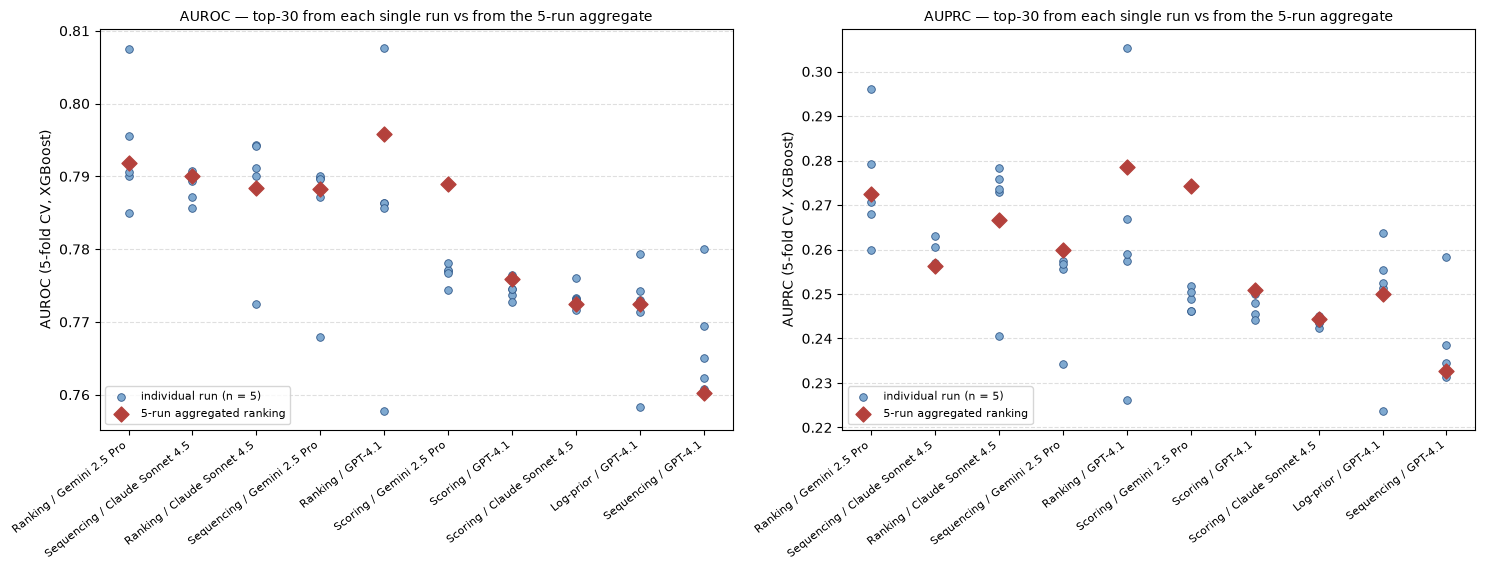

In [20]:
# =============================================================================
# 9-2. Figure — run 별 점 + 집계 순위
# =============================================================================
order = perrun_summary['Procedure'].tolist()
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
for ax, met, lab in [(axes[0], 'auroc', 'AUROC'), (axes[1], 'auprc', 'AUPRC')]:
    for i, nm in enumerate(order):
        v = perrun_detail[perrun_detail.procedure == nm][met].to_numpy()
        ax.scatter([i]*len(v), v, s=30, color='#7FA9D0', ec='#31598A', lw=.6, zorder=3,
                   label='individual run (n = 5)' if i == 0 else None)
        ax.scatter([i], [perrun_summary.set_index('Procedure').loc[nm, f'Aggregated {lab}']],
                   marker='D', s=58, color='#B4413C', zorder=4,
                   label='5-run aggregated ranking' if i == 0 else None)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=38, ha='right', fontsize=8)
    ax.set_ylabel(f'{lab} ({N_SPLITS}-fold CV, XGBoost)')
    ax.grid(axis='y', ls='--', alpha=.4)
    ax.set_title(f'{lab} — top-{TOP_K} from each single run vs from the 5-run aggregate', fontsize=10)
    ax.legend(fontsize=8, loc='lower left')
fig.tight_layout()
fig.savefig(os.path.join(OUT, 'Figure6_perrun_top30.png'), dpi=200, bbox_inches='tight')
plt.show()

## §10. 통계적 변수선택과의 비교 — k = 10 · 30 · 50, AUPRC 포함

§6 은 k = 30 한 지점에서만 비교했다. 그 결과를 "예산 전반에서 통계적 기법이 낫다"로 확장하려면
임상적으로 의미 있는 다른 예산에서도 확인해야 한다.

또한 §6 은 AUROC 만 보고했다. 이 코호트의 섬망 발생률은 8.37% 로 불균형이 크므로 AUPRC 를
함께 보고해야 한다. 여기서는 세 예산 × (10개 LLM 절차 + 3개 통계적 기법)에 대해 AUROC·AUPRC 와
부트스트랩 95% CI 를 모두 내고, 각 예산에서 **최고 LLM 절차 대비 짝지은 차이**를 두 지표 모두에
대해 계산한다.

통계적 기법의 변수선택은 §6 과 동일하게 각 fold 의 훈련셋 안에서만 수행한다. 선택 점수는 k 에
의존하지 않으므로 fold 당 한 번만 계산해 세 예산이 공유한다(상호정보량이 느리기 때문).

In [21]:
# =============================================================================
# 10-1. 통계적 기법의 fold 별 선택 점수 — k 와 무관하므로 한 번만 계산해 재사용
# =============================================================================
K_BUDGETS = [10, 30, 50]
_folds = lambda X, y: list(StratifiedKFold(n_splits=N_SPLITS, shuffle=True,
                                           random_state=CV_SEED).split(X, y))
_FS_CACHE = {}

def fs_scores(name, fold):
    """fold 훈련셋에서 계산한 변수별 선택 점수 (클수록 중요)."""
    key = (name, fold)
    if key in _FS_CACHE:
        return _FS_CACHE[key]
    all_cols, _ = features_to_columns(POOL)
    X, y = build_xy(all_cols, impute=False)
    tr, _ = _folds(X, y)[fold]
    Xtr, ytr = X.iloc[tr], y.iloc[tr]
    if name == 'BASELINE_lasso':
        Z = _SS().fit_transform(Xtr.fillna(Xtr.median()))
        _m = _l1_logreg(C=0.05, seed=CV_SEED).fit(Z, ytr)
        _assert_is_l1(_m, 'BASELINE_lasso')
        sc = np.abs(_m.coef_[0])
    elif name == 'BASELINE_mutual_info':
        sc = mutual_info_classif(Xtr.fillna(Xtr.median()), ytr, random_state=CV_SEED)
    elif name == 'BASELINE_xgb_gain':
        sc = make_model('xgboost', ytr, CV_SEED).fit(Xtr, ytr).feature_importances_
    else:
        raise ValueError(name)
    _FS_CACHE[key] = sc
    return sc

def cv_oof_nested_k(k, name):
    """fold 안에서만 고른 상위 k개로 평가 (누출 없음)."""
    all_cols, _ = features_to_columns(POOL)
    X, y = build_xy(all_cols, impute=False)
    oof, picked = np.zeros(len(y)), []
    for fi, (tr, te) in enumerate(_folds(X, y)):
        cols = X.columns[np.argsort(-fs_scores(name, fi))[:k]].tolist()
        picked.append(cols)
        m = make_model('xgboost', y.iloc[tr], CV_SEED).fit(X.iloc[tr][cols], y.iloc[tr])
        oof[te] = m.predict_proba(X.iloc[te][cols])[:, 1]
    return y.to_numpy(), oof, len(set.intersection(*map(set, picked)))

FS_NAMES = {'BASELINE_lasso': 'L1-regularised logistic regression',
            'BASELINE_mutual_info': 'Mutual information',
            'BASELINE_xgb_gain': 'Gradient-boosted tree gain'}
print('예산:', K_BUDGETS, '| 통계적 기법:', list(FS_NAMES))

예산: [10, 30, 50] | 통계적 기법: ['BASELINE_lasso', 'BASELINE_mutual_info', 'BASELINE_xgb_gain']


In [22]:
# =============================================================================
# 10-2. k = 10 · 30 · 50 에서 LLM 절차와 통계적 기법 비교 (AUROC · AUPRC · 95% CI)
# =============================================================================
_f_ck = os.path.join(OUT, 'Downstream_conventional_ksweep.csv')
_f_cp = os.path.join(OUT, 'Downstream_conventional_paired.csv')

if USE_CACHE and os.path.exists(_f_ck) and os.path.exists(_f_cp):
    conv_df   = pd.read_csv(_f_ck); paired_k = pd.read_csv(_f_cp)
    print(f'[cache] {os.path.basename(_f_ck)}')
else:
    rows, pairs, OOF_K = [], [], {}
    for k in K_BUDGETS:
        for name in sorted(METHOD_VECTORS):
            cols, unavail = features_to_columns(top_k(name, k))
            assert not unavail, f'{name}: 매핑 실패 {unavail}'
            y, p = OOF[name] if k == TOP_K else cv_oof(cols, 'xgboost')
            OOF_K[(k, name)] = (y, p)
            au, alo, ahi = boot_ci(y, p)
            ap, plo, phi = boot_ci(y, p, metric=average_precision_score)
            rows.append({'k': k, 'Selection': nice(name), 'Family': 'LLM-based',
                'AUROC': round(au, 4), 'AUROC 95% CI': f'[{alo:.4f}, {ahi:.4f}]',
                'AUPRC': round(ap, 4), 'AUPRC 95% CI': f'[{plo:.4f}, {phi:.4f}]',
                'Features common to all 5 folds': np.nan})
        for key, label in FS_NAMES.items():
            y, p, stable = cv_oof_nested_k(k, key)
            OOF_K[(k, key)] = (y, p)
            au, alo, ahi = boot_ci(y, p)
            ap, plo, phi = boot_ci(y, p, metric=average_precision_score)
            rows.append({'k': k, 'Selection': label, 'Family': 'Conventional',
                'AUROC': round(au, 4), 'AUROC 95% CI': f'[{alo:.4f}, {ahi:.4f}]',
                'AUPRC': round(ap, 4), 'AUPRC 95% CI': f'[{plo:.4f}, {phi:.4f}]',
                'Features common to all 5 folds': stable})
            print(f'  k={k:3d} {label:36} AUROC {au:.4f}  AUPRC {ap:.4f}', flush=True)

        best_llm = max((n for n in METHOD_VECTORS),
                       key=lambda n: roc_auc_score(*OOF_K[(k, n)]))
        for key, label in FS_NAMES.items():
            y, pA = OOF_K[(k, key)]; _, pB = OOF_K[(k, best_llm)]
            for mlab, mt in [('AUROC', roc_auc_score), ('AUPRC', average_precision_score)]:
                dd, lo, hi, pv = boot_paired(y, pA, pB, metric=mt)
                pairs.append({'k': k, 'Metric': mlab, 'Conventional': label,
                    'Best LLM-based': nice(best_llm), 'Difference': round(dd, 4),
                    '95% CI': f'[{lo:+.4f}, {hi:+.4f}]', 'p': round(pv, 4),
                    'Significant': 'Yes' if (lo > 0 or hi < 0) else 'No'})
    conv_df  = pd.DataFrame(rows).sort_values(['k', 'AUROC'], ascending=[True, False])
    paired_k = pd.DataFrame(pairs).sort_values(['k', 'Metric', 'Difference'],
                                               ascending=[True, True, False])
    conv_df.to_csv(_f_ck, index=False, encoding='utf-8-sig')
    paired_k.to_csv(_f_cp, index=False, encoding='utf-8-sig')

for k in K_BUDGETS:
    print(f'\n--- k = {k} ---')
    display(conv_df[conv_df.k == k][['Selection', 'Family', 'AUROC', 'AUROC 95% CI',
                                     'AUPRC', 'AUPRC 95% CI']])
display(paired_k)

_best_conv = conv_df[conv_df.Family == 'Conventional'].groupby('k').AUROC.max()
_best_llm  = conv_df[conv_df.Family == 'LLM-based'].groupby('k').AUROC.max()
print('\n예산별 최고 통계적 기법 - 최고 LLM 절차 (AUROC):')
for k in K_BUDGETS:
    print(f'  k={k:3d}  {_best_conv[k]:.4f} vs {_best_llm[k]:.4f}  ->  {_best_conv[k]-_best_llm[k]:+.4f}')

  k= 10 L1-regularised logistic regression   AUROC 0.7747  AUPRC 0.2459
  k= 10 Mutual information                   AUROC 0.7455  AUPRC 0.2134
  k= 10 Gradient-boosted tree gain           AUROC 0.7801  AUPRC 0.2545
  k= 30 L1-regularised logistic regression   AUROC 0.8199  AUPRC 0.3234
  k= 30 Mutual information                   AUROC 0.7822  AUPRC 0.2525
  k= 30 Gradient-boosted tree gain           AUROC 0.8282  AUPRC 0.3242
  k= 50 L1-regularised logistic regression   AUROC 0.8261  AUPRC 0.3342
  k= 50 Mutual information                   AUROC 0.8043  AUPRC 0.2833
  k= 50 Gradient-boosted tree gain           AUROC 0.8344  AUPRC 0.3329

--- k = 10 ---


,Selection,Family,AUROC,AUROC 95% CI,AUPRC,AUPRC 95% CI
12,Gradient-boosted tree gain,Conventional,0.7801,"[0.7712, 0.7886]",0.2545,"[0.2404, 0.2702]"
10,L1-regularised logistic regression,Conventional,0.7747,"[0.7663, 0.7831]",0.2459,"[0.2318, 0.2609]"
1,Ranking / Claude Sonnet 4.5,LLM-based,0.7502,"[0.7413, 0.7592]",0.2206,"[0.2074, 0.2352]"
11,Mutual information,Conventional,0.7455,"[0.7367, 0.7545]",0.2134,"[0.2005, 0.2271]"
2,Ranking / Gemini 2.5 Pro,LLM-based,0.7447,"[0.7354, 0.7539]",0.2170,"[0.2044, 0.2310]"
6,Scoring / GPT-4.1,LLM-based,0.7390,"[0.7298, 0.7482]",0.2062,"[0.1942, 0.2201]"
8,Sequencing / Gemini 2.5 Pro,LLM-based,0.7327,"[0.7236, 0.7419]",0.1817,"[0.1721, 0.1930]"
7,Sequencing / Claude Sonnet 4.5,LLM-based,0.7324,"[0.7230, 0.7411]",0.1835,"[0.1735, 0.1951]"
4,Scoring / Claude Sonnet 4.5,LLM-based,0.7321,"[0.7230, 0.7416]",0.1969,"[0.1855, 0.2104]"
3,Ranking / GPT-4.1,LLM-based,0.7308,"[0.7216, 0.7401]",0.1979,"[0.1862, 0.2109]"



--- k = 30 ---


,Selection,Family,AUROC,AUROC 95% CI,AUPRC,AUPRC 95% CI
25,Gradient-boosted tree gain,Conventional,0.8282,"[0.8208, 0.8359]",0.3242,"[0.3076, 0.3425]"
23,L1-regularised logistic regression,Conventional,0.8199,"[0.8123, 0.8277]",0.3234,"[0.3061, 0.3424]"
16,Ranking / GPT-4.1,LLM-based,0.7958,"[0.7876, 0.8041]",0.2786,"[0.2635, 0.2956]"
15,Ranking / Gemini 2.5 Pro,LLM-based,0.7918,"[0.7837, 0.8000]",0.2725,"[0.2577, 0.2896]"
20,Sequencing / Claude Sonnet 4.5,LLM-based,0.7900,"[0.7820, 0.7986]",0.2564,"[0.2427, 0.2728]"
18,Scoring / Gemini 2.5 Pro,LLM-based,0.7889,"[0.7807, 0.7972]",0.2743,"[0.2586, 0.2912]"
14,Ranking / Claude Sonnet 4.5,LLM-based,0.7884,"[0.7805, 0.7967]",0.2667,"[0.2520, 0.2835]"
21,Sequencing / Gemini 2.5 Pro,LLM-based,0.7883,"[0.7799, 0.7966]",0.2598,"[0.2458, 0.2769]"
24,Mutual information,Conventional,0.7822,"[0.7737, 0.7908]",0.2525,"[0.2387, 0.2681]"
19,Scoring / GPT-4.1,LLM-based,0.7759,"[0.7674, 0.7849]",0.2508,"[0.2370, 0.2664]"



--- k = 50 ---


,Selection,Family,AUROC,AUROC 95% CI,AUPRC,AUPRC 95% CI
38,Gradient-boosted tree gain,Conventional,0.8344,"[0.8274, 0.8418]",0.3329,"[0.3158, 0.3507]"
36,L1-regularised logistic regression,Conventional,0.8261,"[0.8189, 0.8341]",0.3342,"[0.3166, 0.3532]"
29,Ranking / GPT-4.1,LLM-based,0.8149,"[0.8071, 0.8226]",0.3143,"[0.2973, 0.3330]"
31,Scoring / Gemini 2.5 Pro,LLM-based,0.8136,"[0.8058, 0.8215]",0.3024,"[0.2863, 0.3212]"
27,Ranking / Claude Sonnet 4.5,LLM-based,0.8128,"[0.8052, 0.8207]",0.2948,"[0.2793, 0.3120]"
34,Sequencing / Gemini 2.5 Pro,LLM-based,0.8102,"[0.8026, 0.8184]",0.2914,"[0.2762, 0.3093]"
33,Sequencing / Claude Sonnet 4.5,LLM-based,0.8068,"[0.7990, 0.8148]",0.2929,"[0.2770, 0.3108]"
37,Mutual information,Conventional,0.8043,"[0.7963, 0.8126]",0.2833,"[0.2684, 0.3005]"
26,Log-prior / GPT-4.1,LLM-based,0.8036,"[0.7959, 0.8113]",0.2862,"[0.2700, 0.3035]"
28,Ranking / Gemini 2.5 Pro,LLM-based,0.8031,"[0.7953, 0.8111]",0.2825,"[0.2673, 0.2988]"


,k,Metric,Conventional,Best LLM-based,Difference,95% CI,p,Significant
5,10,AUPRC,Gradient-boosted tree gain,Ranking / Claude Sonnet 4.5,0.0339,"[+0.0215, +0.0463]",0.000,Yes
1,10,AUPRC,L1-regularised logistic regression,Ranking / Claude Sonnet 4.5,0.0253,"[+0.0121, +0.0388]",0.000,Yes
3,10,AUPRC,Mutual information,Ranking / Claude Sonnet 4.5,-0.0071,"[-0.0189, +0.0046]",0.223,No
4,10,AUROC,Gradient-boosted tree gain,Ranking / Claude Sonnet 4.5,0.0299,"[+0.0228, +0.0368]",0.000,Yes
0,10,AUROC,L1-regularised logistic regression,Ranking / Claude Sonnet 4.5,0.0245,"[+0.0162, +0.0331]",0.000,Yes
2,10,AUROC,Mutual information,Ranking / Claude Sonnet 4.5,-0.0047,"[-0.0123, +0.0027]",0.225,No
11,30,AUPRC,Gradient-boosted tree gain,Ranking / GPT-4.1,0.0456,"[+0.0327, +0.0584]",0.000,Yes
7,30,AUPRC,L1-regularised logistic regression,Ranking / GPT-4.1,0.0448,"[+0.0303, +0.0599]",0.000,Yes
9,30,AUPRC,Mutual information,Ranking / GPT-4.1,-0.0261,"[-0.0406, -0.0131]",0.000,Yes
10,30,AUROC,Gradient-boosted tree gain,Ranking / GPT-4.1,0.0323,"[+0.0266, +0.0379]",0.000,Yes



예산별 최고 통계적 기법 - 최고 LLM 절차 (AUROC):
  k= 10  0.7801 vs 0.7502  ->  +0.0299
  k= 30  0.8282 vs 0.7958  ->  +0.0324
  k= 50  0.8344 vs 0.8149  ->  +0.0195
